In [1]:
import os
import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

BUCKET = os.getenv("S3_BUCKET_NAME")

s3 = boto3.client(
    "s3",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_REGION")
)

columns = ['engine_id', 'cycle', 'op_set_1', 'op_set_2', 'op_set_3'] + [f'sensor_{i}' for i in range(1, 22)]

print(f"Connected to S3 bucket: {BUCKET}")

Connected to S3 bucket: aviation-predictive-maintenance-dataset-chamb


In [2]:
def download_if_missing(local_path, s3_key):
    if not os.path.exists(local_path):
        print(f"Downloading {s3_key} from S3...")
        s3.download_file(BUCKET, s3_key, local_path)
        print("Download successful.")

train_file = os.path.join(RAW_DIR, "train_FD003.txt")
download_if_missing(train_file, "raw/train_FD003.txt")

df = pd.read_csv(train_file, sep=r"\s+", header=None, names=columns)
print("Train shape:", df.shape)
df.head()

Train shape: (24720, 26)


,engine_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583


In [3]:
print("Data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe())

print("\nNumber of engines:", df["engine_id"].nunique())
print("Max cycle:", df["cycle"].max())
print("Average lifecycle:", df.groupby("engine_id")["cycle"].max().mean())

Data types:
engine_id      int64
cycle          int64
op_set_1     float64
op_set_2     float64
op_set_3     float64
sensor_1     float64
sensor_2     float64
sensor_3     float64
sensor_4     float64
sensor_5     float64
sensor_6     float64
sensor_7     float64
sensor_8     float64
sensor_9     float64
sensor_10    float64
sensor_11    float64
sensor_12    float64
sensor_13    float64
sensor_14    float64
sensor_15    float64
sensor_16    float64
sensor_17      int64
sensor_18      int64
sensor_19    float64
sensor_20    float64
sensor_21    float64
dtype: object

Missing values per column:
engine_id    0
cycle        0
op_set_1     0
op_set_2     0
op_set_3     0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
dtype: int

,engine_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,24720.000000,24720.000000,24720.000000,24720.000000,24720.0,24720.00,24720.000000,24720.000000,24720.000000,2.472000e+04,...,24720.000000,24720.000000,24720.000000,24720.000000,2.472000e+04,24720.000000,24720.0,24720.0,24720.000000,24720.000000
mean,48.631877,139.077063,-0.000024,0.000005,100.0,518.67,642.457858,1588.079175,1404.471212,1.462000e+01,...,523.050873,2388.071643,8144.202916,8.396176,3.000000e-02,392.566545,2388.0,100.0,38.988552,23.393024
std,29.348985,98.846675,0.002194,0.000294,0.0,0.00,0.523031,6.810418,9.773178,3.552786e-15,...,3.255314,0.158121,16.504118,0.060512,6.939034e-18,1.761459,0.0,0.0,0.248865,0.149234
min,1.000000,1.000000,-0.008600,-0.000600,100.0,518.67,640.840000,1564.300000,1377.060000,1.462000e+01,...,517.770000,2386.930000,8099.680000,8.156300,3.000000e-02,388.000000,2388.0,100.0,38.170000,22.872600
25%,23.000000,62.000000,-0.001500,-0.000200,100.0,518.67,642.080000,1583.280000,1397.187500,1.462000e+01,...,521.150000,2388.010000,8134.510000,8.360600,3.000000e-02,391.000000,2388.0,100.0,38.830000,23.296200
50%,47.000000,124.000000,-0.000000,-0.000000,100.0,518.67,642.400000,1587.520000,1402.910000,1.462000e+01,...,521.980000,2388.070000,8141.200000,8.398300,3.000000e-02,392.000000,2388.0,100.0,38.990000,23.391600
75%,74.000000,191.000000,0.001500,0.000300,100.0,518.67,642.790000,1592.412500,1410.600000,1.462000e+01,...,523.840000,2388.140000,8149.230000,8.437000,3.000000e-02,394.000000,2388.0,100.0,39.140000,23.483300
max,100.000000,525.000000,0.008600,0.000700,100.0,518.67,645.110000,1615.390000,1441.160000,1.462000e+01,...,537.400000,2388.610000,8290.550000,8.570500,3.000000e-02,399.000000,2388.0,100.0,39.850000,23.950500



Number of engines: 100
Max cycle: 525
Average lifecycle: 247.2


In [4]:
max_cycles = df.groupby("engine_id")["cycle"].max().reset_index()
max_cycles.columns = ["engine_id", "max_cycle"]

df = df.merge(max_cycles, on="engine_id", how="left")
df["RUL"] = df["max_cycle"] - df["cycle"]

df["label_30"] = (df["RUL"] <= 30).astype(int)
df.drop(columns=["max_cycle"], inplace=True)

print(df[["engine_id", "cycle", "RUL", "label_30"]].head())
print("\nLabel distribution:")
print(df["label_30"].value_counts())

   engine_id  cycle  RUL  label_30
0          1      1  258         0
1          1      2  257         0
2          1      3  256         0
3          1      4  255         0
4          1      5  254         0

Label distribution:
label_30
0    21620
1     3100
Name: count, dtype: int64


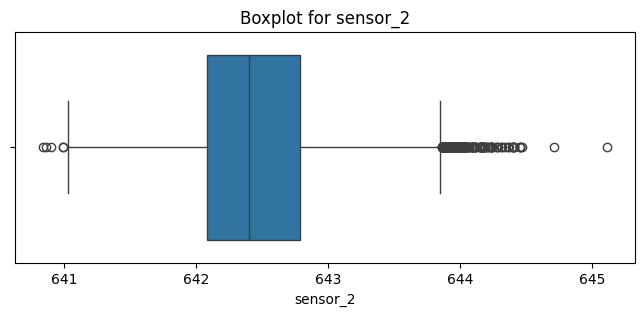

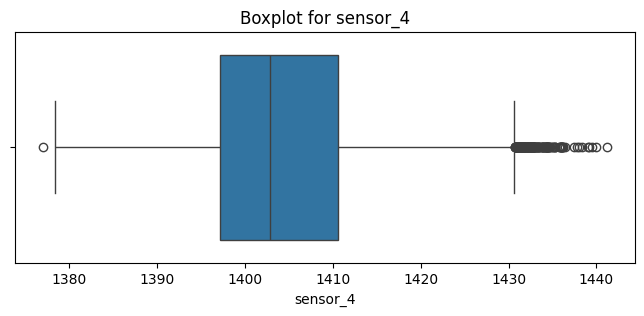

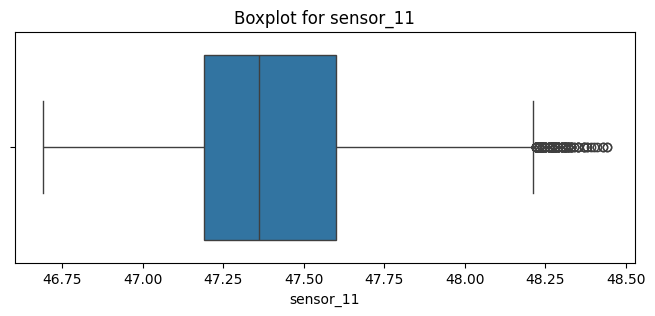

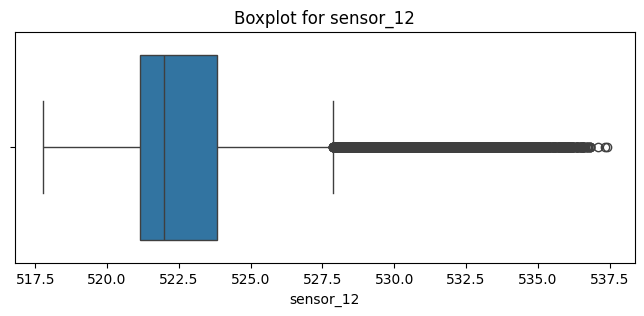

In [5]:
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]

sample_sensors = ["sensor_2", "sensor_4", "sensor_11", "sensor_12"]

for col in sample_sensors:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

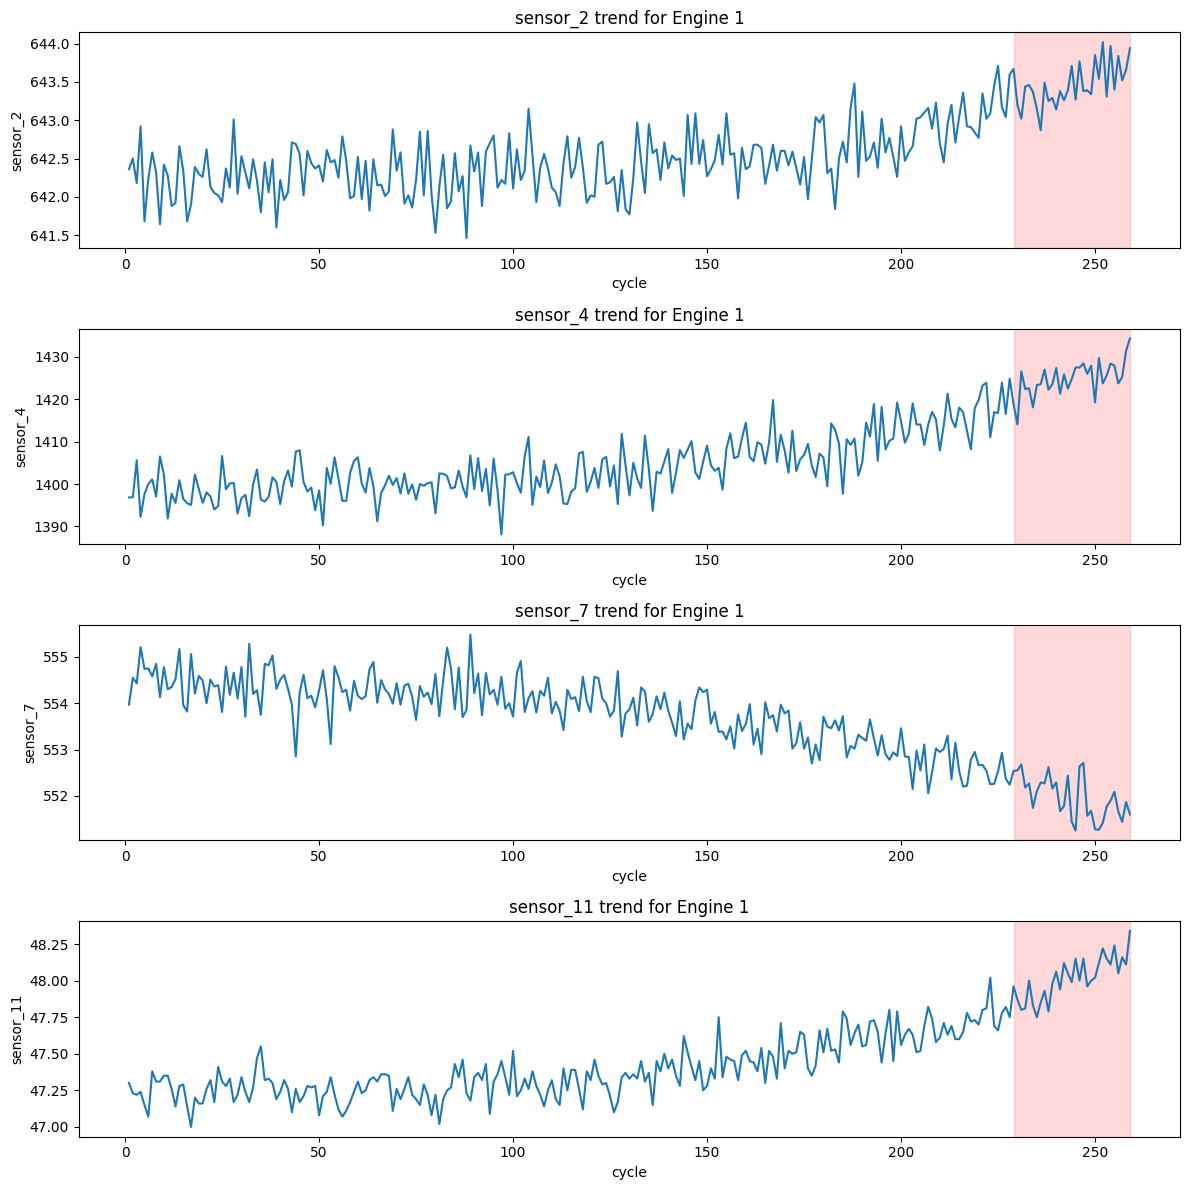

In [6]:
target_sensors = ["sensor_2", "sensor_4", "sensor_7", "sensor_11"]
engine_1 = df[df["engine_id"] == 1]

fig, axes = plt.subplots(len(target_sensors), 1, figsize=(12, 12))

for i, sensor in enumerate(target_sensors):
    sns.lineplot(ax=axes[i], data=engine_1, x="cycle", y=sensor)
    axes[i].set_title(f"{sensor} trend for Engine 1")
    axes[i].axvspan(engine_1["cycle"].max() - 30, engine_1["cycle"].max(), color="red", alpha=0.15)

plt.tight_layout()
plt.show()

Low variance columns: ['sensor_1', 'sensor_18', 'sensor_19', 'sensor_16', 'sensor_5', 'sensor_10', 'op_set_3']


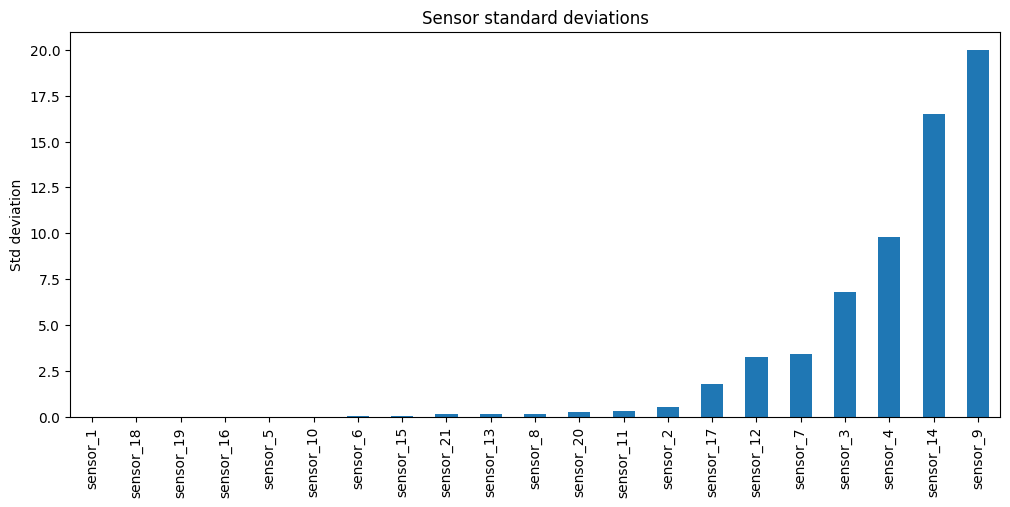

In [7]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
sensor_std = df[sensor_cols].std().sort_values()

flat_sensors = sensor_std[sensor_std < 0.005].index.tolist()

if df["op_set_3"].std() < 0.005:
    low_variance_cols = flat_sensors + ["op_set_3"]
else:
    low_variance_cols = flat_sensors.copy()

print("Low variance columns:", low_variance_cols)

plt.figure(figsize=(12, 5))
sensor_std.plot(kind="bar")
plt.title("Sensor standard deviations")
plt.ylabel("Std deviation")
plt.show()

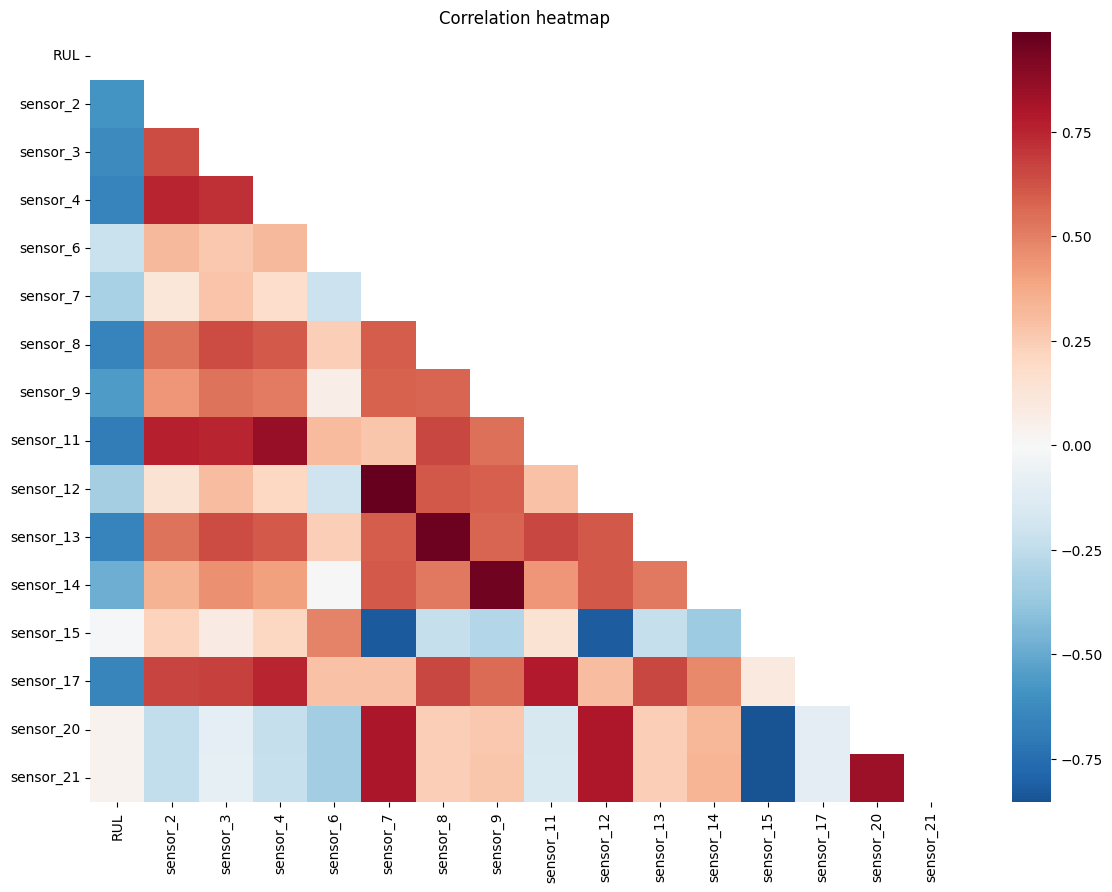

Top negatively correlated sensors with RUL:
sensor_11   -0.688915
sensor_4    -0.657224
sensor_13   -0.656340
sensor_8    -0.655345
sensor_17   -0.649220
Name: RUL, dtype: float64

Top positively correlated sensors with RUL:
sensor_7    -0.315048
sensor_6    -0.215352
sensor_15   -0.016501
sensor_21    0.033465
sensor_20    0.037782
Name: RUL, dtype: float64


In [8]:
cols_for_corr = ["RUL"] + [c for c in sensor_cols if c not in flat_sensors]
corr = df[cols_for_corr].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0)
plt.title("Correlation heatmap")
plt.show()

rul_corr = corr["RUL"].drop("RUL").sort_values()
print("Top negatively correlated sensors with RUL:")
print(rul_corr.head(5))

print("\nTop positively correlated sensors with RUL:")
print(rul_corr.tail(5))

In [9]:
predictive_sensors = [c for c in sensor_cols if c not in flat_sensors]

df_feat = df.copy()

# engine age features
df_feat["engine_age"] = df_feat["cycle"]
df_feat["cycle_norm"] = df_feat["cycle"] / df_feat.groupby("engine_id")["cycle"].transform("max")

# rolling mean and std
rolling_mean = (
    df_feat.groupby("engine_id")[predictive_sensors]
    .rolling(window=5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)
rolling_mean.columns = [f"{c}_mean_5" for c in predictive_sensors]

rolling_std = (
    df_feat.groupby("engine_id")[predictive_sensors]
    .rolling(window=5, min_periods=1)
    .std()
    .reset_index(level=0, drop=True)
)
rolling_std.columns = [f"{c}_std_5" for c in predictive_sensors]

# delta from first cycle
first_cycle_vals = df_feat.groupby("engine_id")[predictive_sensors].transform("first")
delta_from_start = df_feat[predictive_sensors] - first_cycle_vals
delta_from_start.columns = [f"{c}_delta_start" for c in predictive_sensors]

df_feat = pd.concat([df_feat, rolling_mean, rolling_std, delta_from_start], axis=1).fillna(0)

print("Train feature shape:", df_feat.shape)
df_feat.head()

Train feature shape: (24720, 75)


,engine_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_8_delta_start,sensor_9_delta_start,sensor_11_delta_start,sensor_12_delta_start,sensor_13_delta_start,sensor_14_delta_start,sensor_15_delta_start,sensor_17_delta_start,sensor_20_delta_start,sensor_21_delta_start
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0000,0,0.00,0.0000
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,0.04,-0.39,-0.07,0.11,0.02,7.53,0.0157,1,-0.12,0.0954
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,0.07,8.06,-0.08,-0.28,-0.01,4.85,-0.0345,0,-0.26,0.0132
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,0.04,2.40,-0.06,0.18,0.07,1.24,-0.0368,1,-0.15,-0.0586
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,0.08,13.97,-0.15,0.27,0.02,2.48,-0.0377,1,0.03,0.1046


In [10]:
train_clean_path = os.path.join(PROCESSED_DIR, "train_clean.parquet")
train_feat_path = os.path.join(PROCESSED_DIR, "train_features_FD003.parquet")

df.to_parquet(train_clean_path, index=False)
df_feat.to_parquet(train_feat_path, index=False)

s3.upload_file(train_clean_path, BUCKET, "processed/train_clean.parquet")
s3.upload_file(train_feat_path, BUCKET, "processed/train_features_FD003.parquet")

print("Uploaded train outputs to S3.")

Uploaded train outputs to S3.


In [11]:
test_file = os.path.join(RAW_DIR, "test_FD003.txt")
rul_file = os.path.join(RAW_DIR, "RUL_FD003.txt")

download_if_missing(test_file, "raw/test_FD003.txt")
download_if_missing(rul_file, "raw/RUL_FD003.txt")

test_df = pd.read_csv(test_file, sep=r"\s+", header=None, names=columns)
true_rul = pd.read_csv(rul_file, sep=r"\s+", header=None, names=["remaining_life"])
true_rul["engine_id"] = np.arange(1, len(true_rul) + 1)

print("Test shape:", test_df.shape)
print("Ground truth shape:", true_rul.shape)

Test shape: (16596, 26)
Ground truth shape: (100, 2)


In [12]:
test_df_feat = test_df.copy()

test_df_feat["engine_age"] = test_df_feat["cycle"]
test_df_feat["cycle_norm"] = test_df_feat["cycle"] / test_df_feat.groupby("engine_id")["cycle"].transform("max")

rolling_mean_test = (
    test_df_feat.groupby("engine_id")[predictive_sensors]
    .rolling(window=5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)
rolling_mean_test.columns = [f"{c}_mean_5" for c in predictive_sensors]

rolling_std_test = (
    test_df_feat.groupby("engine_id")[predictive_sensors]
    .rolling(window=5, min_periods=1)
    .std()
    .reset_index(level=0, drop=True)
)
rolling_std_test.columns = [f"{c}_std_5" for c in predictive_sensors]

first_cycle_vals_test = test_df_feat.groupby("engine_id")[predictive_sensors].transform("first")
delta_from_start_test = test_df_feat[predictive_sensors] - first_cycle_vals_test
delta_from_start_test.columns = [f"{c}_delta_start" for c in predictive_sensors]

test_df_feat = pd.concat(
    [test_df_feat, rolling_mean_test, rolling_std_test, delta_from_start_test],
    axis=1
).fillna(0)

print("Test feature shape:", test_df_feat.shape)

Test feature shape: (16596, 73)


In [13]:
test_last = test_df_feat.groupby("engine_id").tail(1).copy()
test_last = test_last.merge(true_rul, on="engine_id", how="left")
test_last["label_30"] = (test_last["remaining_life"] <= 30).astype(int)

print("Final test-last shape:", test_last.shape)
test_last.head()

Final test-last shape: (100, 75)


,engine_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_11_delta_start,sensor_12_delta_start,sensor_13_delta_start,sensor_14_delta_start,sensor_15_delta_start,sensor_17_delta_start,sensor_20_delta_start,sensor_21_delta_start,remaining_life,label_30
0,1,233,0.0021,0.0002,100.0,518.67,642.59,1592.40,1409.87,14.62,...,0.44,6.16,0.29,25.29,-0.0794,2,0.36,0.1211,44,0
1,2,124,-0.0005,0.0002,100.0,518.67,642.56,1587.42,1409.69,14.62,...,0.35,-0.79,0.07,-3.36,-0.0064,-1,-0.18,-0.1675,51,0
2,3,234,-0.0011,-0.0004,100.0,518.67,642.75,1591.93,1417.66,14.62,...,0.46,6.96,0.32,31.33,-0.0378,4,0.09,0.1706,27,1
3,4,68,-0.0014,-0.0000,100.0,518.67,642.28,1584.68,1406.56,14.62,...,-0.29,-0.70,-0.03,-1.12,-0.0611,-2,-0.24,0.0618,120,0
4,5,138,-0.0001,-0.0003,100.0,518.67,642.15,1580.59,1397.26,14.62,...,-0.15,2.18,0.57,9.77,-0.0299,1,0.07,0.1193,101,0


In [15]:
train_cols = set(df_feat.columns)
test_cols = set(test_df_feat.columns)

print("Columns only in train:", sorted(train_cols - test_cols))
print("Columns only in test:", sorted(test_cols - train_cols))
print("Feature sets match:", train_cols == test_cols)

exclude = {"RUL", "label_30"}
print((train_cols - exclude) == test_cols)

Columns only in train: ['RUL', 'label_30']
Columns only in test: []
Feature sets match: False
True


In [16]:
test_feat_path = os.path.join(PROCESSED_DIR, "test_features_FD003.parquet")
test_last_path = os.path.join(PROCESSED_DIR, "test_last_with_truth_FD003.parquet")

test_df_feat.to_parquet(test_feat_path, index=False)
test_last.to_parquet(test_last_path, index=False)

s3.upload_file(test_feat_path, BUCKET, "processed/test_features_FD003.parquet")
s3.upload_file(test_last_path, BUCKET, "processed/test_last_with_truth_FD003.parquet")

print("Uploaded test outputs to S3.")

Uploaded test outputs to S3.


In [17]:
summary = {
    "train_rows": len(df),
    "train_feature_rows": len(df_feat),
    "test_rows": len(test_df),
    "test_last_rows": len(test_last),
    "num_engines_train": df["engine_id"].nunique(),
    "num_engines_test": test_df["engine_id"].nunique(),
    "dropped_low_variance_columns": low_variance_cols,
    "predictive_sensor_count": len(predictive_sensors),
    "final_train_feature_count": df_feat.shape[1],
    "final_test_feature_count": test_df_feat.shape[1],
}

summary

{'train_rows': 24720,
 'train_feature_rows': 24720,
 'test_rows': 16596,
 'test_last_rows': 100,
 'num_engines_train': 100,
 'num_engines_test': 100,
 'dropped_low_variance_columns': ['sensor_1',
  'sensor_18',
  'sensor_19',
  'sensor_16',
  'sensor_5',
  'sensor_10',
  'op_set_3'],
 'predictive_sensor_count': 15,
 'final_train_feature_count': 75,
 'final_test_feature_count': 73}